<h1>Table of contents</h1>

<div class="alert alert-block alert-info" style="margin-top: 20px">
    <ol>
        <li><a href="#Data">Data</a></li>
        <li><a href="#Selecting-And-Preprocessing">Selecting And Preprocessing</a></li>
        <li><a href="#Model">Model</a></li>
        <li><a href="#Evaluation">Evaluation</a></li>
    </ol>
</div>
<br>
<hr>

# import libs

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import linear_model
from sklearn.metrics import r2_score
from scipy.stats import norm

<h1 id="Data">Data</h1>

In [2]:
df = pd.read_csv("../data/FuelConsumption.csv")
df

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1062,2014,VOLVO,XC60 AWD,SUV - SMALL,3.0,6,AS6,X,13.4,9.8,11.8,24,271
1063,2014,VOLVO,XC60 AWD,SUV - SMALL,3.2,6,AS6,X,13.2,9.5,11.5,25,264
1064,2014,VOLVO,XC70 AWD,SUV - SMALL,3.0,6,AS6,X,13.4,9.8,11.8,24,271
1065,2014,VOLVO,XC70 AWD,SUV - SMALL,3.2,6,AS6,X,12.9,9.3,11.3,25,260


<h1 id = "Selecting-And-Preprocessing">Selecting And Preprocessing</h1>

In [3]:
cdf = df[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB','CO2EMISSIONS']]
df.head(10)

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244
5,2014,ACURA,RLX,MID-SIZE,3.5,6,AS6,Z,11.9,7.7,10.0,28,230
6,2014,ACURA,TL,MID-SIZE,3.5,6,AS6,Z,11.8,8.1,10.1,28,232
7,2014,ACURA,TL AWD,MID-SIZE,3.7,6,AS6,Z,12.8,9.0,11.1,25,255
8,2014,ACURA,TL AWD,MID-SIZE,3.7,6,M6,Z,13.4,9.5,11.6,24,267
9,2014,ACURA,TSX,COMPACT,2.4,4,AS5,Z,10.6,7.5,9.2,31,212


In [4]:
df.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


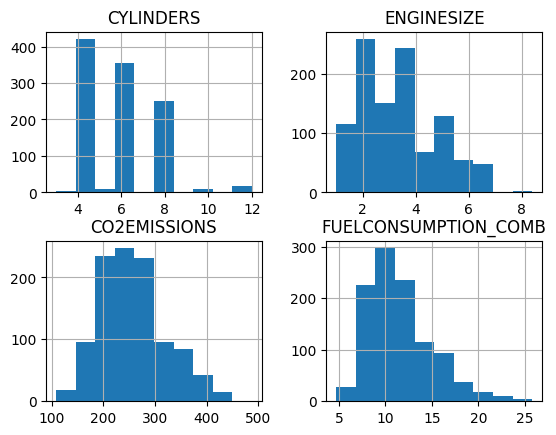

In [5]:
viz = cdf[['CYLINDERS','ENGINESIZE','CO2EMISSIONS','FUELCONSUMPTION_COMB']]
viz.hist()
plt.show()

#### Probability density function
<div style= "text-align:center; font-size:26px; margin:25px 0;">
$$
f(x) = \frac{1}{\sigma \sqrt{2\pi}}
e^{-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2}
$$
</div>

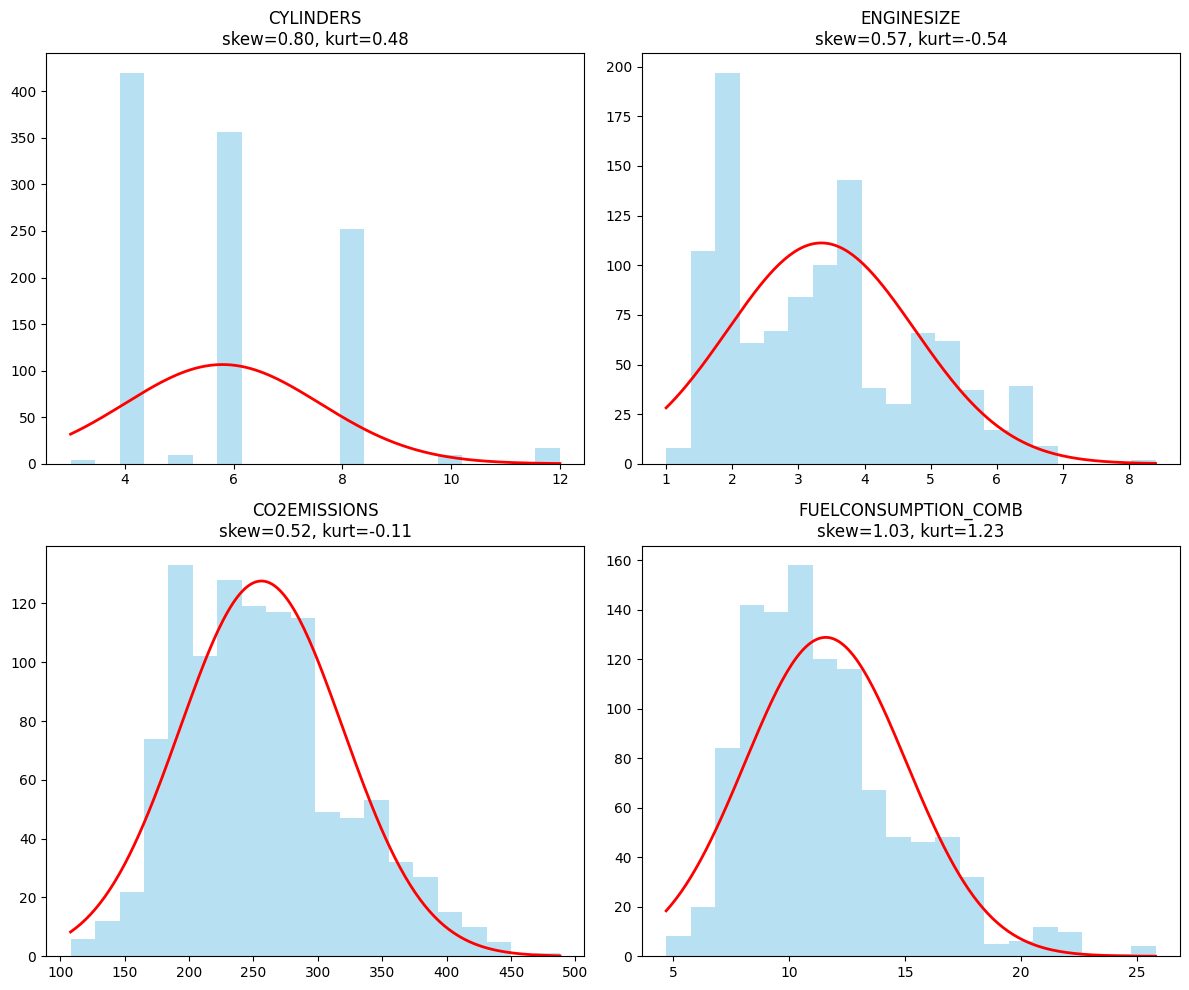

In [6]:
viz = cdf[['CYLINDERS','ENGINESIZE','CO2EMISSIONS','FUELCONSUMPTION_COMB']]

plt.figure(figsize=(12,10))

for i, col in enumerate(viz.columns):
    data = viz[col]
    mu = data.mean()
    sigma = data.std()
    
    skew = data.skew()
    kurt = data.kurt()

    plt.subplot(2, 2, i+1)

    counts, bins, _ = plt.hist(data, bins=20, alpha=0.6, color='skyblue')

    x = np.linspace(data.min(), data.max(), 200)
    y = norm.pdf(x, mu, sigma)
    
    y = y * len(data) * (bins[1] - bins[0]) # for scaling to normal count
    plt.plot(x, y, 'r', linewidth=2)
    plt.title(f"{col}\nskew={skew:.2f}, kurt={kurt:.2f}")

plt.tight_layout()
plt.show()

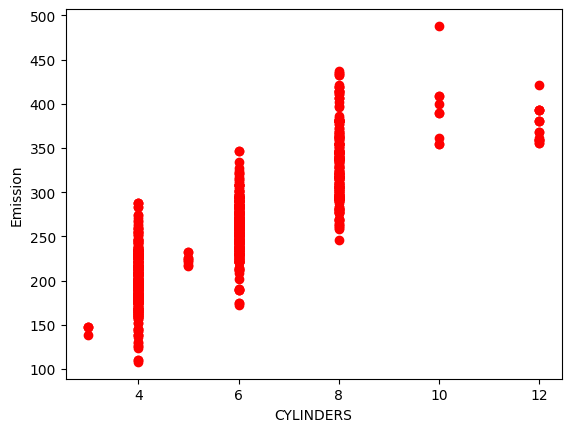

In [7]:
plt.plot(cdf.CYLINDERS, cdf.CO2EMISSIONS,  'ro')
plt.xlabel("CYLINDERS")
plt.ylabel("Emission")
plt.show()

Text(0, 0.5, 'Emission')

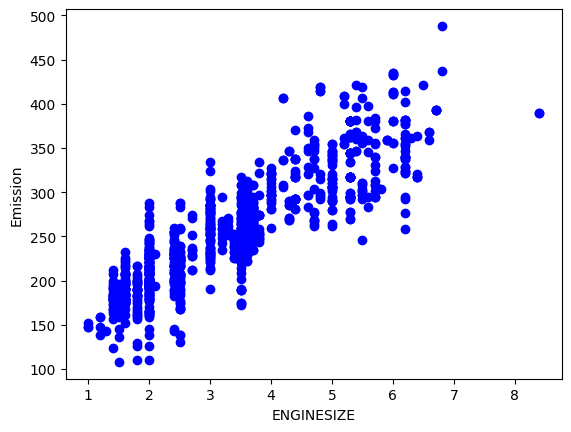

In [8]:
plt.plot(cdf.ENGINESIZE, cdf.CO2EMISSIONS,  'bo')
plt.xlabel("ENGINESIZE")
plt.ylabel("Emission")

Text(0, 0.5, 'Emission')

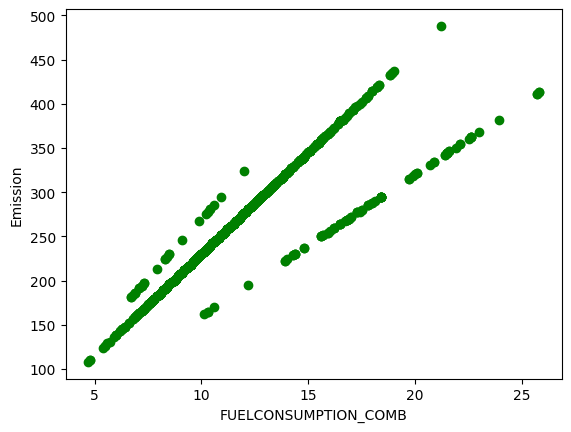

In [9]:
plt.plot(cdf.FUELCONSUMPTION_COMB, cdf.CO2EMISSIONS,  'go')
plt.xlabel("FUELCONSUMPTION_COMB")
plt.ylabel("Emission")

In [10]:
np.random.randn?

Signature: np.random.randn(*args)
Docstring:
randn(d0, d1, ..., dn)

Return a sample (or samples) from the "standard normal" distribution.

.. note::
    This is a convenience function for users porting code from Matlab,
    and wraps `standard_normal`. That function takes a
    tuple to specify the size of the output, which is consistent with
    other NumPy functions like `numpy.zeros` and `numpy.ones`.

.. note::
    New code should use the
    `~numpy.random.Generator.standard_normal`
    method of a `~numpy.random.Generator` instance instead;
    please see the :ref:`random-quick-start`.

If positive int_like arguments are provided, `randn` generates an array
of shape ``(d0, d1, ..., dn)``, filled
with random floats sampled from a univariate "normal" (Gaussian)
distribution of mean 0 and variance 1. A single float randomly sampled
from the distribution is returned if no argument is provided.

Parameters
----------
d0, d1, ..., dn : int, optional
    The dimensions of the returned 

# seperating data (80% 20%)
##### seperating data into two groups to train and test our model

In [11]:
mask = np.random.rand(df['ENGINESIZE'].size) < 0.8
train = cdf[mask]
test = cdf [~ mask]
print(mask)
train

[ True  True  True ...  True  True  True]


,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
0,2.0,4,8.5,196
1,2.4,4,9.6,221
2,1.5,4,5.9,136
3,3.5,6,11.1,255
4,3.5,6,10.6,244
...,...,...,...,...
1061,3.2,6,11.2,258
1063,3.2,6,11.5,264
1064,3.0,6,11.8,271
1065,3.2,6,11.3,260


<h1 id = "Model">Model</h1>

### Model with Emgiesize feature

In [12]:
regr = linear_model.LinearRegression()
train_x = np.asanyarray(train[['ENGINESIZE']])
train_y = np.asanyarray(train[['CO2EMISSIONS']])
regr.fit (train_x, train_y)
# The coefficients
print ('Coefficients: ', regr.coef_[0][0])
print ('Intercept: ',regr.intercept_[0])

Coefficients:  39.45763777881299
Intercept:  124.3087513160429


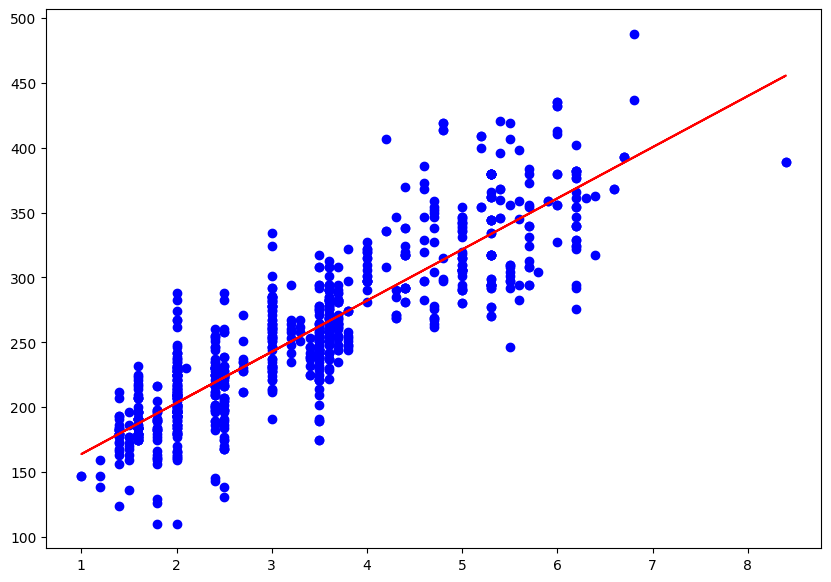

In [13]:
plt.figure(figsize=(10,7))
plt.scatter(train_x,train_y,color = 'blue')
plt.plot(train_x , regr.coef_[0]*train_x + regr.intercept_ , 'r-')
print('')

### Model with Fuelconsumption_comb feature

In [14]:
regr_fuel = linear_model.LinearRegression()
x_fuel = np.asanyarray(train[['FUELCONSUMPTION_COMB']])
y_fuel = np.asanyarray(train['CO2EMISSIONS'])
regr_fuel.fit(x_fuel,y_fuel)
print(regr_fuel.coef_[0])
regr_fuel.intercept_

16.240965470720546


np.float64(68.18908793781341)

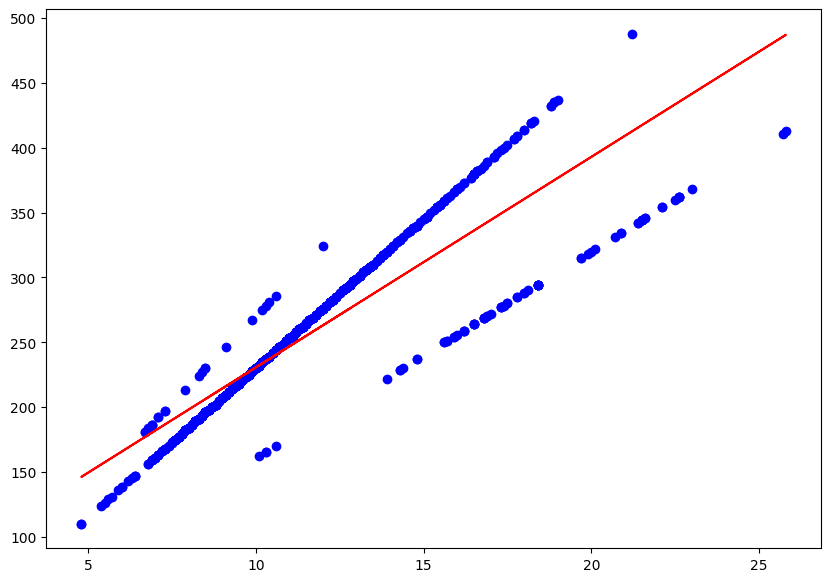

In [15]:
plt.figure(figsize=(10,7))
plt.scatter(x_fuel,y_fuel,color = 'blue')
plt.plot(x_fuel , regr_fuel.coef_[0]*x_fuel + regr_fuel.intercept_ , 'r-')
print('')

<h1 id = "Evaluation">Evaluation</h1>

In [16]:
test_x = np.asanyarray(test[['ENGINESIZE']])
test_y = np.asanyarray(test[['CO2EMISSIONS']])
test_y_ = regr.predict(test_x)
print('MAE : ',np.mean(np.absolute(test_y-test_y_)))
print('MSE : ',np.mean(np.square(test_y-test_y_)))
print('R_score : ',r2_score(test_y,test_y_))

MAE :  25.037128275180315
MSE :  1059.7114958736524
R_score :  0.7416305705145811


In [17]:
test_x_fuel = np.asanyarray(test[['FUELCONSUMPTION_COMB']])
test_y_fuel = np.asanyarray(test[['CO2EMISSIONS']])
test_y_fuel_ = regr_fuel.predict(test_x_fuel)
print('MAE : ',np.mean(np.absolute(test_y_fuel-test_y_fuel_)))
print('MSE : ',np.mean(np.square(test_y_fuel-test_y_fuel_)))
print('R_score : ',r2_score(test_y_fuel,test_y_fuel_))

MAE :  67.59692310275547
MSE :  7433.08300262178
R_score :  0.8013531206515199


- later i use others mothed to apply for seperating values